# Test Logger
Test logging capabilities including decorators and analyser

In [1]:
from config_loader import CONFIG
from logger import Logger, LogLevels, LogAnalyser, time_tracker
import random
import time
from datetime import datetime

In [2]:
logger = Logger()

class A: 
    @time_tracker(logger) # logger as a fixed attribute in a class
    def time_simulation1(self):
        time.sleep(random.uniform(0, 0.3))
        
class B:
    def __init__(self, logger):
        self.logger = logger
    
    @time_tracker(lambda self:self.logger) # logger as a class attribute
    def time_simulation2(self):
        time.sleep(random.uniform(0.3, 0.5))

      
@time_tracker(logger) # logger as a fixed attribute in a func
def time_simulation3():
    time.sleep(random.uniform(0.5, 1))

15:33:36.064855 -> [  unknown   ]    INFO    | Logger initialized, print:    INFO   , write to file:   DEBUG   


In [3]:
a = A()
logger2 = Logger()
b = B(logger2)
for i in range(10):
    a.time_simulation1()
    b.time_simulation2()
    time_simulation3()

15:26:23.216426 -> [  unknown   ]    INFO    | Logger initialized, print:    INFO   , write to file:   DEBUG   


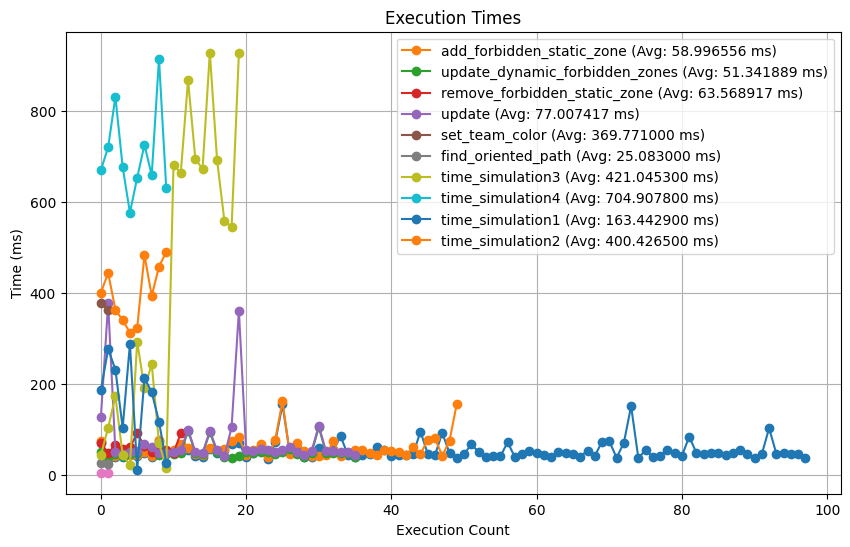

In [4]:
log_analyser = LogAnalyser(f"logs/{datetime.now().strftime('%Y-%m-%d')}.log")
log_analyser.analyse_time_tracker()

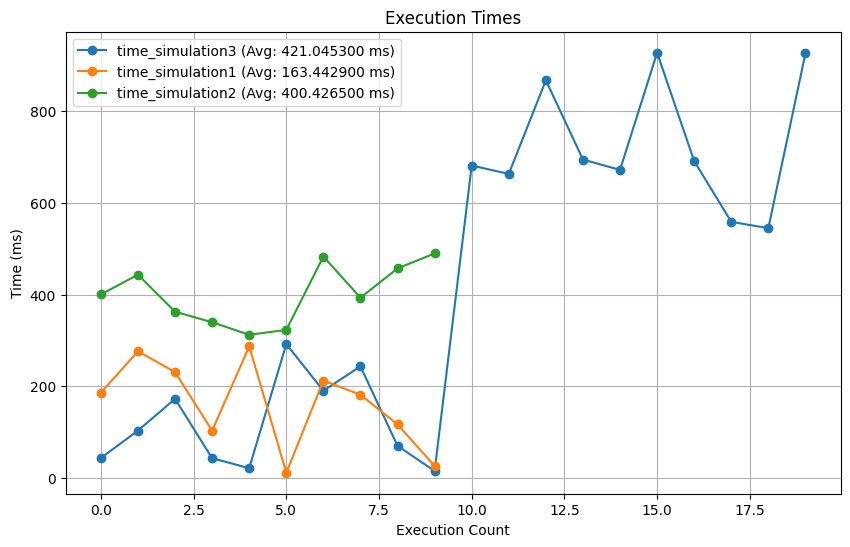

In [5]:
log_analyser.analyse_time_tracker(func_names=["time_simulation1", "time_simulation2", "time_simulation3"])

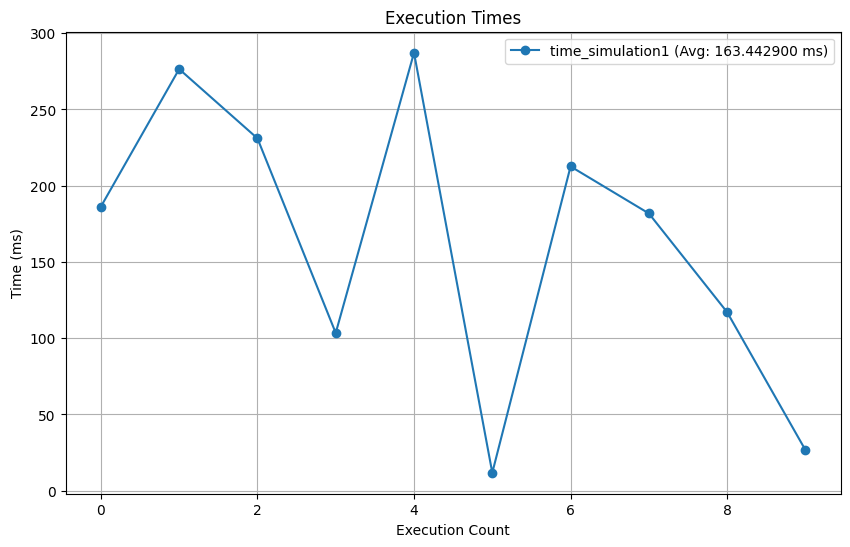

In [6]:
log_analyser.analyse_time_tracker(func_names="time_simulation1")